# AdventureWorks — Exploratory Data Analysis

Reads the already-built, already-tested Gold marts (`fct_sales`, `dim_*`, `bridge_order_sales_reason`)
straight from the local DuckDB file produced by `just build` — no separate extract, per this repo's
"Python is a thin layer" convention. Every number below is computed directly against those marts, so it
reconciles by construction to the same figures the dbt tests and the Superset dashboard use (no parallel
metric layer).

Covers, at minimum: **product mix**, **customer/channel distribution** (online vs. reseller), **geography
distribution**, and **"Promotion" discount impact** — feeding the commercial recommendations doc (P4-10)
and cross-checking the hero KPIs (P4-01/P4-07) from an independent angle.

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")


def find_repo_root(start: Path) -> Path:
    """Walk up from `start` to the repo root (identified by `justfile`).

    Makes the notebook cwd-agnostic: it runs the same whether launched from the repo
    root (`jupyter nbconvert --execute notebooks/eda.ipynb`) or from within
    `notebooks/` (interactive use).
    """
    for candidate in (start, *start.parents):
        if (candidate / "justfile").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root (no justfile in any parent dir)")


REPO_ROOT = find_repo_root(Path.cwd())
DB_PATH = REPO_ROOT / "data" / "adventureworks.duckdb"

con = duckdb.connect(str(DB_PATH), read_only=True)
tables_query = "select table_name from information_schema.tables where table_schema = 'main'"
con.sql(f"{tables_query} order by 1").show()

┌──────────────────────────────────────────────────┐
│                    table_name                    │
│                     varchar                      │
├──────────────────────────────────────────────────┤
│ bridge_order_sales_reason                        │
│ dim_credit_card                                  │
│ dim_customer                                     │
│ dim_date                                         │
│ dim_geography                                    │
│ dim_order_status                                 │
│ dim_product                                      │
│ dim_sales_reason                                 │
│ fct_sales                                        │
│ stg_adventure_works__address                     │
│ stg_adventure_works__countryregion               │
│ stg_adventure_works__creditcard                  │
│ stg_adventure_works__customer                    │
│ stg_adventure_works__person                      │
│ stg_adventure_works__product                

## Product mix

`fct_sales` joined to `dim_product` (category/subcategory), aggregating gross revenue, units, and order
lines by product category — the same `gross_revenue`/`order_qty` columns the reconciliation tests and the
hero KPIs use.

In [2]:
product_mix = con.sql('''
    select
        p.category_name,
        sum(f.gross_revenue) as gross_revenue,
        sum(f.order_qty) as units_sold,
        count(*) as order_lines
    from fct_sales as f
    inner join dim_product as p using (product_key)
    group by 1
    order by 2 desc
''').df()
product_mix

,category_name,gross_revenue,units_sold,order_lines
0,Bikes,"95,145,813.35","90,268.00",40031
1,Components,"11,807,808.02","49,044.00",18698
2,Clothing,"2,141,507.02","73,670.00",21394
3,Accessories,"1,278,760.91","61,932.00",41194


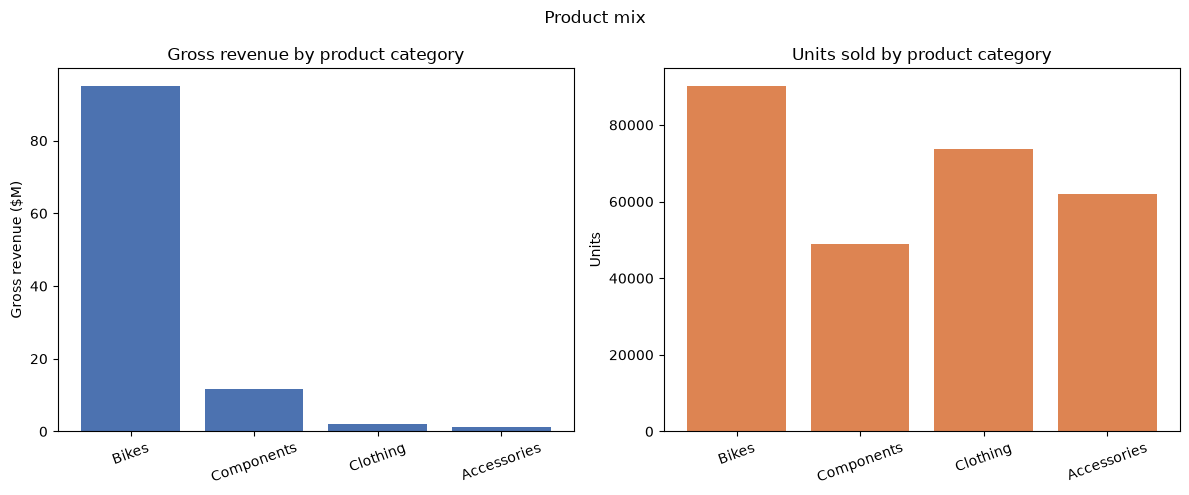

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(product_mix["category_name"], product_mix["gross_revenue"] / 1e6, color="#4C72B0")
axes[0].set_title("Gross revenue by product category")
axes[0].set_ylabel("Gross revenue ($M)")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(product_mix["category_name"], product_mix["units_sold"], color="#DD8452")
axes[1].set_title("Units sold by product category")
axes[1].set_ylabel("Units")
axes[1].tick_params(axis="x", rotation=20)

fig.suptitle("Product mix")
fig.tight_layout()
plt.show()

**Insight.** Revenue is heavily concentrated in **Bikes**: ~$95.1M of the ~$110.4M all-channel gross
(~86%), despite Bikes accounting for only ~90.3K of the ~296K units sold (~30%) — bikes are the
high-ticket item, everything else is comparatively low-value/high-volume. **Accessories** is the mirror
image: ~62K units (~21% of volume) for only ~$1.3M (~1.2% of revenue). **Components** (~$11.8M, ~49K
units) sit between the two, largely reflecting parts sold with/around bike purchases. For a commercial
lens, this means AOV and revenue-growth levers sit almost entirely on the Bikes line — accessory/clothing
volume drives footfall/units, not revenue.

## Channel distribution (online vs. reseller)

`fct_sales.is_online` splits the grain (ADR-0010): individual customers buying online (`is_online = true`)
vs. resellers/stores buying wholesale (`is_online = false`, per `dim_customer.customer_type`).

In [4]:
channel_mix = con.sql('''
    select
        case when f.is_online then 'Online (individual)' else 'Reseller (store)' end as channel,
        count(distinct f.sales_order_number) as orders,
        sum(f.gross_revenue) as gross_revenue,
        sum(f.order_qty) as units_sold,
        sum(f.gross_revenue) / count(distinct f.sales_order_number) as avg_order_value
    from fct_sales as f
    group by 1
    order by 3 desc
''').df()
channel_mix

,channel,orders,gross_revenue,units_sold,avg_order_value
0,Reseller (store),3806,"81,015,212.09","214,516.00","21,286.18"
1,Online (individual),27659,"29,358,677.22","60,398.00","1,061.45"


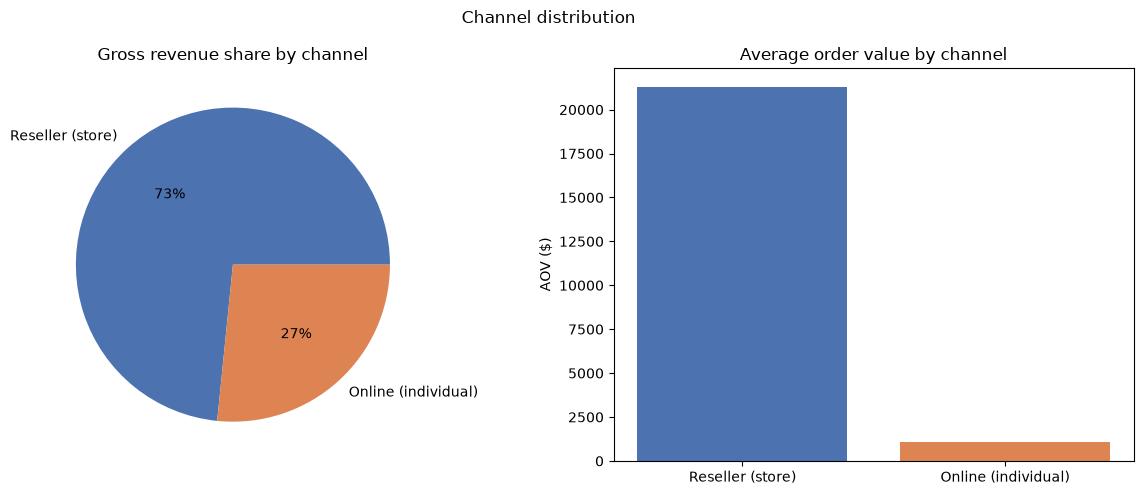

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(
    channel_mix["gross_revenue"],
    labels=channel_mix["channel"],
    autopct="%1.0f%%",
    colors=["#4C72B0", "#DD8452"],
)
axes[0].set_title("Gross revenue share by channel")

axes[1].bar(channel_mix["channel"], channel_mix["avg_order_value"], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Average order value by channel")
axes[1].set_ylabel("AOV ($)")

fig.suptitle("Channel distribution")
fig.tight_layout()
plt.show()

**Insight.** Reseller/store orders are far fewer (3,806 vs. 27,659 online orders — resellers are ~12% of
order count) but generate the majority of revenue: ~$81.0M (~73% of the $110.4M all-channel gross) at an
AOV of roughly $21,300, against ~$29.4M (~27%) from online individual buyers at an AOV of roughly $1,060 —
a ~20x gap. This is a classic B2B-wholesale-vs-B2C-retail split: resellers place large, infrequent bulk
orders, online shoppers place small, frequent ones. It also explains why the P4-01 hero KPIs (Total
Revenue, Orders, AOV) move very differently depending on whether the sales-channel filter is applied — a
dashboard viewer filtering to "online only" will see revenue drop by ~73% even though order *count* only
drops by ~12%.

## Geography distribution

`fct_sales` joined to `dim_geography` (ship-to address, ADR-0005) — revenue and order count by
country.

In [6]:
geography_mix = con.sql('''
    select
        g.country,
        sum(f.gross_revenue) as gross_revenue,
        count(distinct f.sales_order_number) as orders0
    from fct_sales as f
    inner join dim_geography as g using (geography_key)
    group by 1
    order by 2 desc
''').df()
geography_mix

,country,gross_revenue,orders0
0,United States,"63,308,723.21",12041
1,Canada,"16,441,125.01",4067
2,Australia,"10,683,870.01",6843
3,United Kingdom,"7,702,839.10",3219
4,France,"7,291,471.92",2672
5,Germany,"4,945,860.07",2623


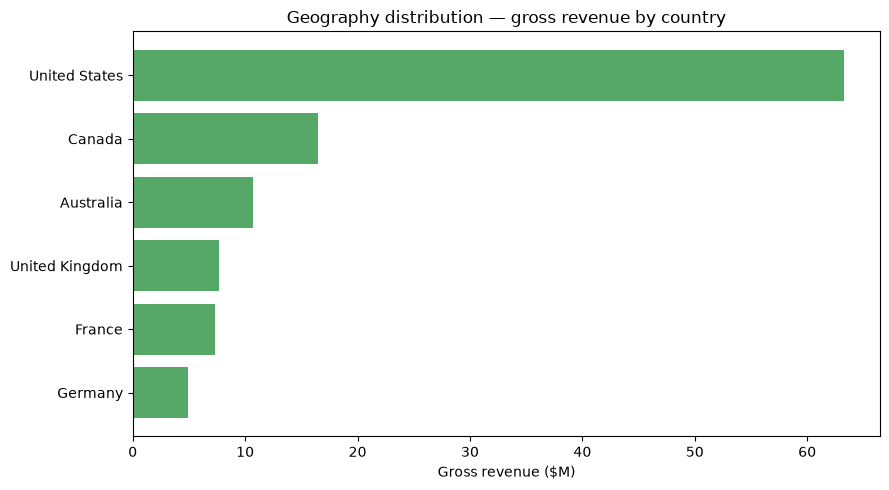

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(geography_mix["country"][::-1], geography_mix["gross_revenue"][::-1] / 1e6, color="#55A868")
ax.set_xlabel("Gross revenue ($M)")
ax.set_title("Geography distribution — gross revenue by country")
fig.tight_layout()
plt.show()

**Insight.** The United States alone accounts for ~$63.3M of the ~$110.4M all-channel gross (~57%) —
more than the next five countries combined (~$46.6M). Canada (~$16.4M) and Australia (~$10.7M) are the
next-largest markets, with the UK, France, and Germany each contributing roughly $5-8M. AdventureWorks'
revenue base is US-anchored with a long tail of smaller international markets; any geography-targeted
promotion (question d/e in the dashboard) should be read against this heavy US skew, not an even
split.

## Promotion / discount impact

`fct_sales` carries no reason FK by design (ADR-0003) — a reason-filtered view joins through
`bridge_order_sales_reason` (grain: order x reason) to `dim_sales_reason`. `dim_sales_reason` groups
individual reasons under a `sales_reason_type`; the reason literally named `"On Promotion"` carries
`sales_reason_type = 'Promotion'` — the P3-04 singular test's exact string filter
(`sales_reason_name = 'Promotion'`) does not match any row (no reason is named exactly `"Promotion"`), so
this notebook filters on `sales_reason_type = 'Promotion'` to get the real, non-empty set the business
question actually means. That gap in the exact-string filter is a pre-existing nuance in P3-04's test,
called out here for P4-07/P4-10, not something this notebook silently patches.

In [8]:
promo_orders = con.sql('''
    select distinct b.sales_order_number
    from bridge_order_sales_reason as b
    inner join dim_sales_reason as r using (sales_reason_key)
    where r.sales_reason_type = 'Promotion'
''')

# No-fan-out check (same invariant P3-04 proves): direct fct_sales sum for the matched orders
# must equal the sum computed by joining through the bridge, for this single-reason filter.
direct_gross = con.sql('''
    select round(sum(f.gross_revenue), 2) as gross
    from fct_sales as f
    where f.sales_order_number in (select sales_order_number from promo_orders)
''').fetchone()[0]

bridge_gross = con.sql('''
    select round(sum(f.gross_revenue), 2) as gross
    from fct_sales as f
    inner join bridge_order_sales_reason as b using (sales_order_number)
    inner join dim_sales_reason as r using (sales_reason_key)
    where r.sales_reason_type = 'Promotion'
''').fetchone()[0]

assert direct_gross == bridge_gross, (
    f"bridge join fanned out gross for the Promotion filter: {direct_gross} != {bridge_gross}"
)
print(f"No fan-out confirmed: direct gross == bridge-joined gross == {direct_gross:,.2f}")

promo_summary = con.sql('''
    select
        count(distinct f.sales_order_number) as promo_orders,
        sum(f.gross_revenue) as promo_gross,
        sum(f.order_qty) as promo_units
    from fct_sales as f
    where f.sales_order_number in (select sales_order_number from promo_orders)
''').df()
promo_summary

No fan-out confirmed: direct gross == bridge-joined gross == 6,361,828.95


,promo_orders,promo_gross,promo_units
0,3515,"6,361,828.95","7,390.00"


In [9]:
discount_by_channel = con.sql('''
    select
        case when is_online then 'Online (individual)' else 'Reseller (store)' end as channel,
        sum(discount_amount) as total_discount,
        sum(case when discount_amount > 0 then 1 else 0 end) as discounted_lines,
        count(*) as total_lines
    from fct_sales
    group by 1
''').df()
discount_by_channel

,channel,total_discount,discounted_lines,total_lines
0,Online (individual),0.00,0.00,60398
1,Reseller (store),"527,507.91","3,282.00",60919


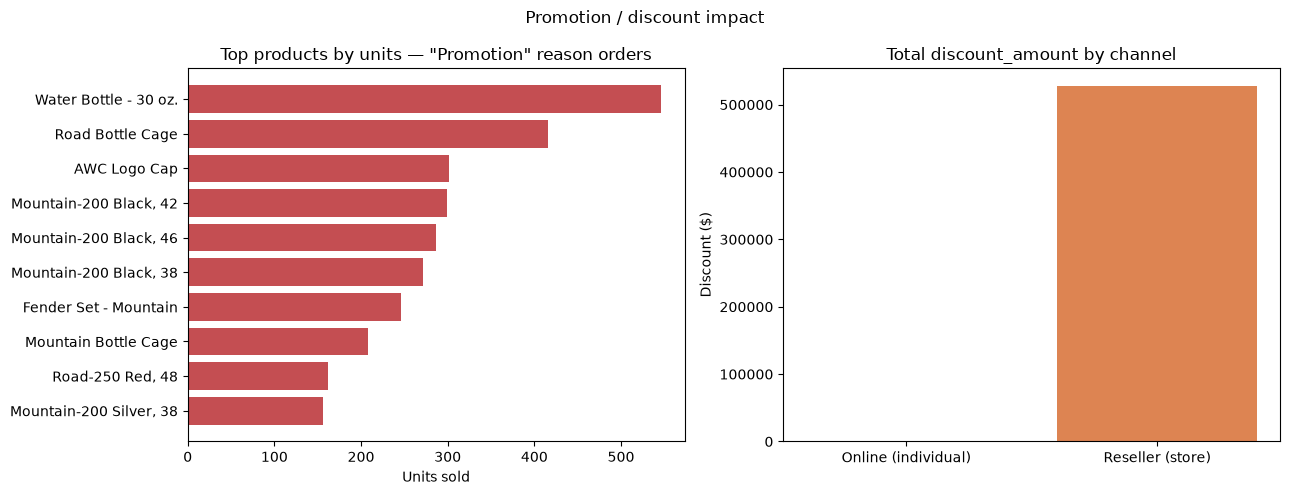

,product_name,units_sold
0,Water Bottle - 30 oz.,546.00
1,Road Bottle Cage,416.00
2,AWC Logo Cap,301.00
3,"Mountain-200 Black, 42",299.00
4,"Mountain-200 Black, 46",286.00
5,"Mountain-200 Black, 38",272.00
6,Fender Set - Mountain,246.00
7,Mountain Bottle Cage,208.00
8,"Road-250 Red, 48",162.00
9,"Mountain-200 Silver, 38",156.00


In [10]:
top_promo_products = con.sql('''
    select p.product_name, sum(f.order_qty) as units_sold
    from fct_sales as f
    inner join dim_product as p using (product_key)
    where f.sales_order_number in (select sales_order_number from promo_orders)
    group by 1
    order by 2 desc
    limit 10
''').df()

promo_names = top_promo_products["product_name"][::-1]
promo_units = top_promo_products["units_sold"][::-1]
discount_channels = discount_by_channel["channel"]
discount_totals = discount_by_channel["total_discount"]
channel_colors = ["#4C72B0", "#DD8452"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(promo_names, promo_units, color="#C44E52")
axes[0].set_title('Top products by units — "Promotion" reason orders')
axes[0].set_xlabel("Units sold")

axes[1].bar(discount_channels, discount_totals, color=channel_colors)
axes[1].set_title("Total discount_amount by channel")
axes[1].set_ylabel("Discount ($)")

fig.suptitle("Promotion / discount impact")
fig.tight_layout()
plt.show()
top_promo_products

**Insight.** 3,515 online orders (~12.7% of the 27,659 online orders) cite `"On Promotion"` as their
purchase reason, worth ~$6.36M gross (~21.7% of online-channel revenue) and ~7,390 units — confirmed
identical ($6,361,828.95) whether computed directly on `fct_sales` or via the bridge join, so the
reason-filtered figure does not fan out (same invariant P3-04's singular test proves structurally). The
top promotion-driven product is the **Water Bottle - 30 oz.** (546 units), followed by the **Road Bottle
Cage** (416) and **AWC Logo Cap** (301) — low-ticket, high-frequency accessories, not bikes.

A separate, important nuance for Silvana's "promotions vs. data-driven decisions" question: `On Promotion`
is a *self-reported reason* individual online customers pick at checkout — it has **zero** overlap with
the fact's actual `discount_amount` column, because every dollar of real, applied discount
(**$527,507.91** total, ADR-0001/0004/0005) sits entirely on the **reseller/store channel**
(60,919 reseller lines vs. 0 on the 60,398 online lines) — resellers get negotiated wholesale discounts,
online individual customers do not, regardless of the reason they cite. "Promotion" as a stated *reason*
and "discount" as an applied *dollar amount* are two structurally distinct phenomena in this data, sitting
on opposite channels — a recommendation that conflates them would misread the mechanism entirely.

## Summary of key insights

- **Product mix**: Bikes drive ~86% of gross revenue from ~30% of units — the commercial lever is Bikes,
  not accessory/clothing volume.
- **Channel**: Resellers are ~12% of orders but ~73% of revenue (AOV ~$21.3K vs. ~$1.06K online) — a ~20x
  AOV gap between wholesale and retail.
- **Geography**: The US alone is ~57% of gross revenue, more than the next five countries combined.
- **Promotion**: ~12.7% of online orders self-report "On Promotion", worth ~21.7% of online revenue and
  confirmed non-fan-out via the bridge join — but the *dollar* discount is a reseller-only phenomenon
  ($527,507.91, entirely on the store channel), unrelated to the online "Promotion" reason tag.

These figures cross-check the P4-01 hero KPIs and the P4-07 Promotion-impact tile from an independent
angle (direct DuckDB SQL over the marts, not the Superset chart engine), and feed P4-10's recommendations
doc with concrete, reconciled numbers.